# Análisis exploratorio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from funciones_auxilares import *

# 1. Contexto

El conjunto de datos esta compuesto por 6 variables las cuales son las siguientes:
* **F - Frecuencia (Hertz Hz).** La frecuencia a la que se mide/analiza el ruido aerodinámico generado por el perfil.
* **alpha - Ángulo de ataque (Grados º).** El ángulo entre la cuerda del perfil y el flujo incidente.
* **c - Longiutd de cuerda (metros m).** La cuerda del perfil.
* **U_infinity - Velocidad de la corriente libre (m/s).** La velocidad de flujo lejos del perfil.
* **delta - Espesor de desplazamiento en la cara de succión (metros m).** El espesor de desplazamiento de la capa límite en la cara de succión.
* **SSPL - Scaled Sound Pressure Level (dB).** El nivel de presión sonora escalado.

***NOTA:** La variable a predecir será SSPL para conocer el sonido de la presión sonora que produce el avión según su inclinación.*

**OBJETIVO:** El objetivo de este cuaderno es el de realizar el análisis exploratorio del conjuhto de datos para su posterior utilización en modelos de regresión para la identificación de contrafácticos mediante el uso del framework FUCO

# 2. Carga de datos y revisión básica de calidad

In [2]:
# Se realiza la carga de los datos
df = pd.read_csv("AirfoilSelfNoise.csv", sep=',')

print("--------------- VISUALIZACIÓN DE CABECERA ---------------")
print(df.head())

print()
print("--------------- RESUMEN BÁSICO ---------------")
print(df.info())

--------------- VISUALIZACIÓN DE CABECERA ---------------
      f  alpha       c  U_infinity     delta     SSPL
0   800    0.0  0.3048        71.3  0.002663  126.201
1  1000    0.0  0.3048        71.3  0.002663  125.201
2  1250    0.0  0.3048        71.3  0.002663  125.951
3  1600    0.0  0.3048        71.3  0.002663  127.591
4  2000    0.0  0.3048        71.3  0.002663  127.461

--------------- RESUMEN BÁSICO ---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB
None


Como puede observarse el conjunto de datos está compuesto por 6 variables las cuales son 5 predictoras (f, alpha, c, U_infinity y delta) junto a la variable a predecir que es SSPL. Dentro del conjunto de datos podemos encontrar que la variable *f* es la única numérica entera mientras que el resto es numérica decimal. Adicionalmente, dentro de cada una de las variables del conjunto de datos, ninguna de ellas contiene elementos vacíos en los 1503 registros que componen el conjunto de datos.

# 3. Estadística descriptiva y análisis univariante

A través de este apartado se pasa a realizar la analítica descriptiva de cada una de las variables que componen el conjunto de datos para conocer sus distribuciones y los valores que estas almacenan.

## 3.1 Estadística descriptiva

In [3]:
print("--------------- MÉTRICAS ESTADÍSTICAS BÁSICAS ---------------")
print(df.describe())

--------------- MÉTRICAS ESTADÍSTICAS BÁSICAS ---------------
                  f        alpha            c   U_infinity        delta  \
count   1503.000000  1503.000000  1503.000000  1503.000000  1503.000000   
mean    2886.380572     6.782302     0.136548    50.860745     0.011140   
std     3152.573137     5.918128     0.093541    15.572784     0.013150   
min      200.000000     0.000000     0.025400    31.700000     0.000401   
25%      800.000000     2.000000     0.050800    39.600000     0.002535   
50%     1600.000000     5.400000     0.101600    39.600000     0.004957   
75%     4000.000000     9.900000     0.228600    71.300000     0.015576   
max    20000.000000    22.200000     0.304800    71.300000     0.058411   

              SSPL  
count  1503.000000  
mean    124.835943  
std       6.898657  
min     103.380000  
25%     120.191000  
50%     125.721000  
75%     129.995500  
max     140.987000  


Como puede ser observado el conjunto de datos cuenta con 6 variables las cuales dan información a 1503 registros. Entre las varaibles puede observarse como existe una alta diferencia en cuanto a las escalas de los valores como a los rangos de estas. Por otro lado, se puede observar como para *f* y *delta* su media se encuentra muy por encima de su mediana por lo que existe un sesgo hacia la derecha. Por último, con respecto a la variable objetivo puede ser observado como la distribución de valores se encuentra dentro de un rango aceptable.

## 3.2 Análisis univariante

Con respecto al análisis univeriante, destaca lo siguiente:
* *Variable f.* Existen valores atípicos por encima por lo que hay que revisar la situación y evaluar si es necesario eliminarlos.
* *Variabel delta.* Existen valores atípicos por encima por lo que hay que revisar la situación y evaluar si es necesario eliminarlos.

=== ESTADISTICA DESCRIPTIVA 'f' ===
count     1503.000000
mean      2886.380572
std       3152.573137
min        200.000000
25%        800.000000
50%       1600.000000
75%       4000.000000
max      20000.000000


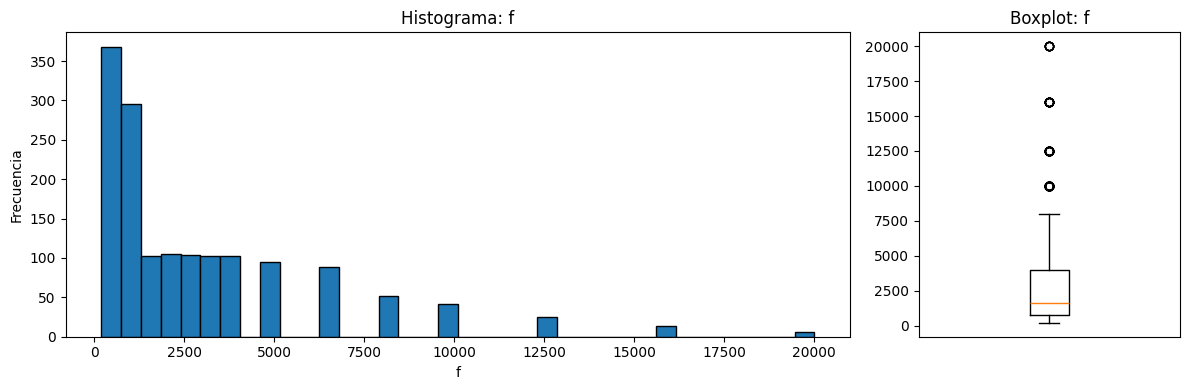


=== ESTADISTICA DESCRIPTIVA 'alpha' ===
count    1503.000000
mean        6.782302
std         5.918128
min         0.000000
25%         2.000000
50%         5.400000
75%         9.900000
max        22.200000


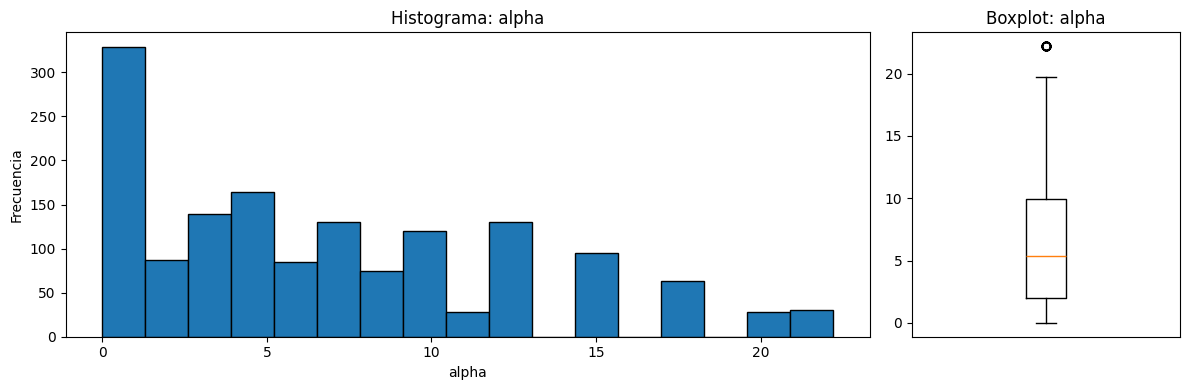


=== ESTADISTICA DESCRIPTIVA 'c' ===
count    1503.000000
mean        0.136548
std         0.093541
min         0.025400
25%         0.050800
50%         0.101600
75%         0.228600
max         0.304800


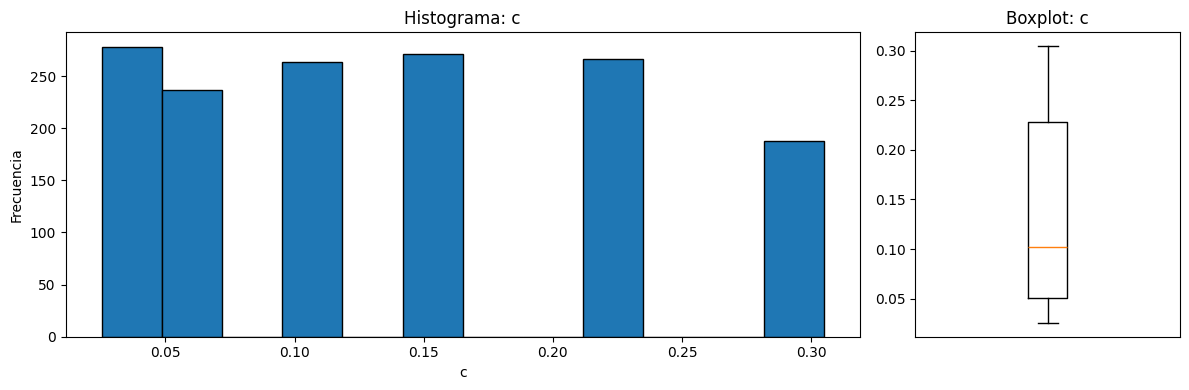


=== ESTADISTICA DESCRIPTIVA 'U_infinity' ===
count    1503.000000
mean       50.860745
std        15.572784
min        31.700000
25%        39.600000
50%        39.600000
75%        71.300000
max        71.300000


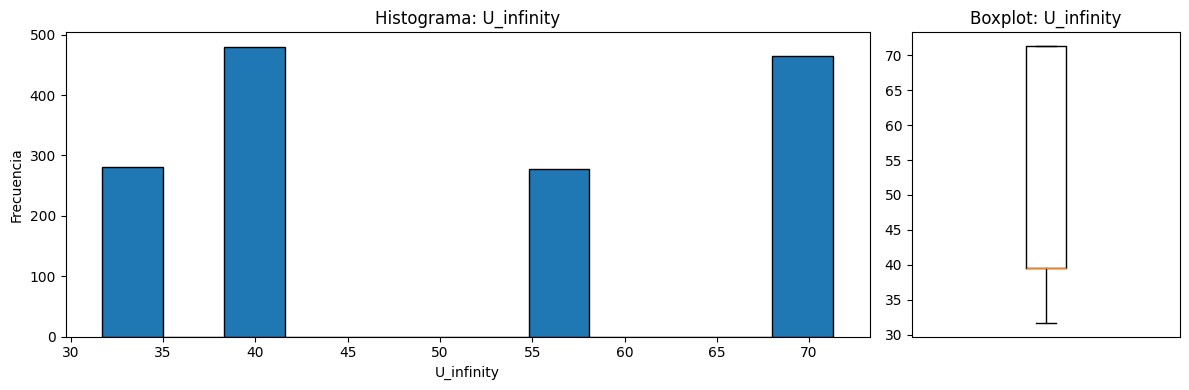


=== ESTADISTICA DESCRIPTIVA 'delta' ===
count    1503.000000
mean        0.011140
std         0.013150
min         0.000401
25%         0.002535
50%         0.004957
75%         0.015576
max         0.058411


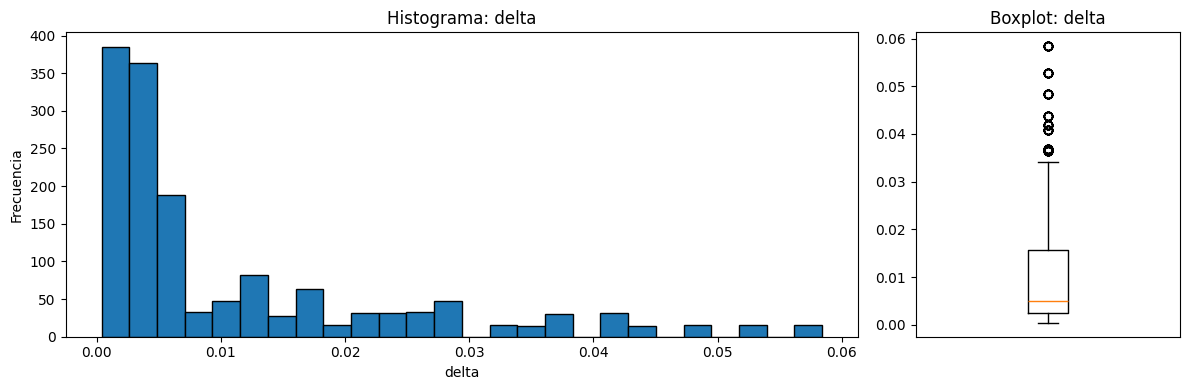


=== ESTADISTICA DESCRIPTIVA 'SSPL' ===
count    1503.000000
mean      124.835943
std         6.898657
min       103.380000
25%       120.191000
50%       125.721000
75%       129.995500
max       140.987000


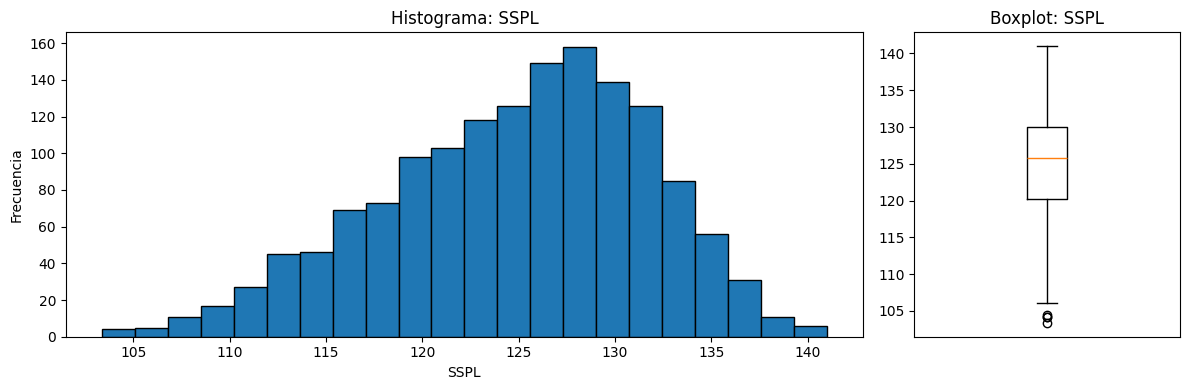

In [4]:
# Ejemplo de uso:
for col in df.columns:
    visualizacion_uni_hist_boxplot(df, col)
    print()


# 3.2 Análisis correlaciones

A través de este apartado se pasa a realizar el análisis de correlaciones entre las variables que componen el cojunto de datos con el fin de conocer las relaciones y tendencias que existen entre ellas.

## 3.2.1 Correlación de pearson 

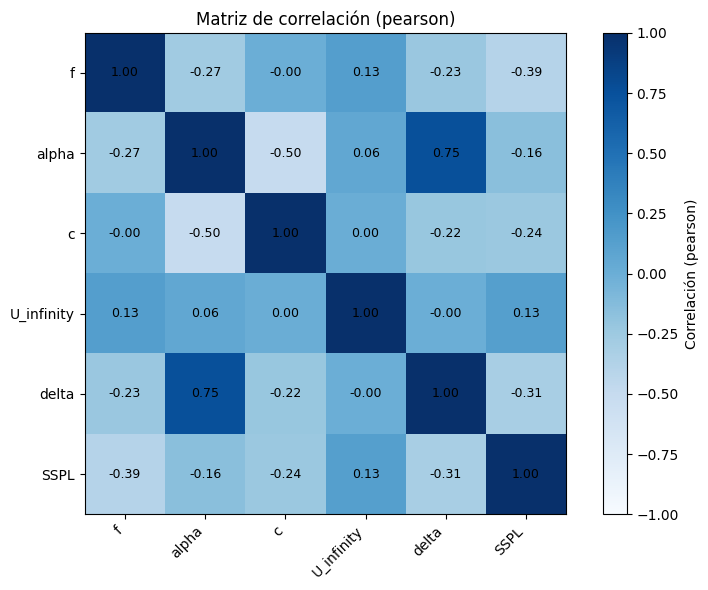

In [5]:
plot_corr_matrix(df, method="pearson")

Como se puede observar en la matriz de correlaciones, existe una alta correlación positiva entre la variable *alpha* y la variable *delta* mientras que la correlación de *alpha* con la variable *C* es alta pero de manera negativa. Por otro lado, puede ser observado como que con respecto a la variable a predecir (*SSPL*) la correlación con el resto de variables es negativa a excepción de la variable *U_infinity*. Adicionalmente, puede ser observado como entre el resto de variables no se observar correlaciones altamente reseñables.

## 3.2.2 Correlación de Spearman

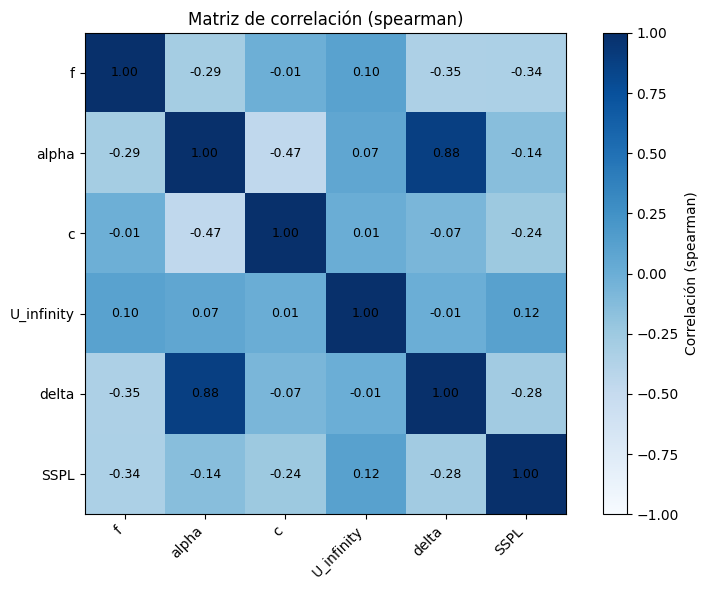

In [6]:
plot_corr_matrix(df, method="spearman")

Como se puede observar en la matriz de correlaciones, existe una alta correlación positiva entre la variable *alpha* y la variable *delta* mientras que la correlación de *alpha* con la variable *C* es alta pero de manera negativa. Por otro lado, puede ser observado como que con respecto a la variable a predecir (*SSPL*) la correlación con el resto de variables es negativa a excepción de la variable *U_infinity*. Adicionalmente, puede ser observado como entre el resto de variables no se observar correlaciones altamente reseñables.

## 3.2.3 Relaciones bivariantes 

Con respecto a las relaciones de las variables predictoras con la variables a predecir, no se observan situaciones ni elemento reseñables.

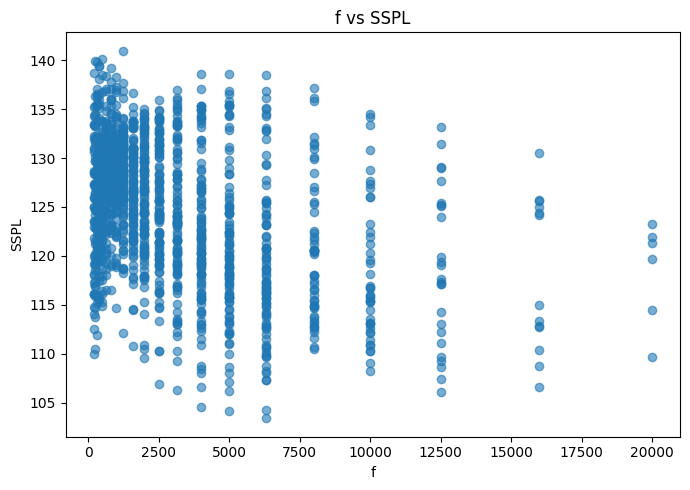

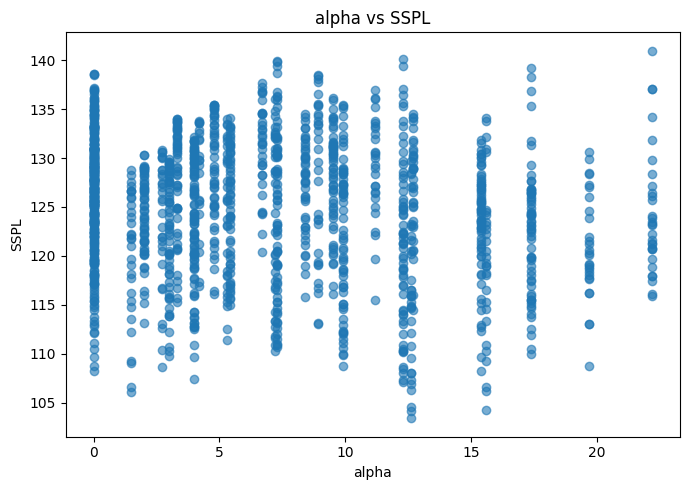

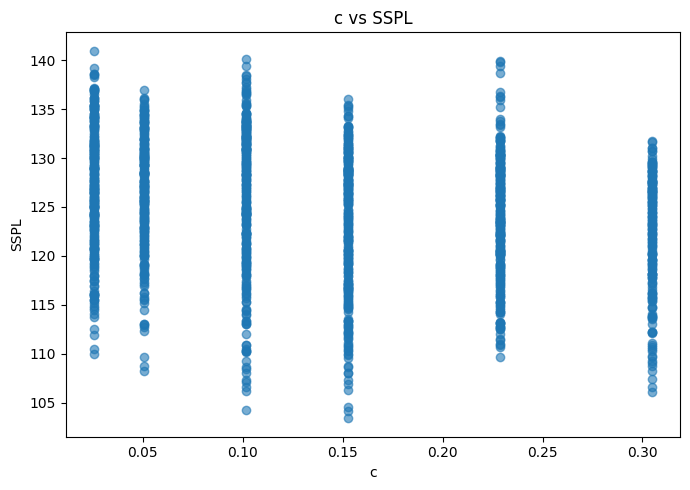

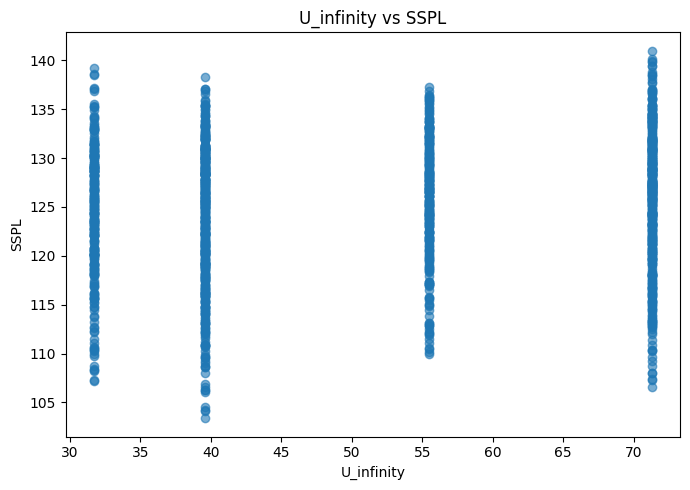

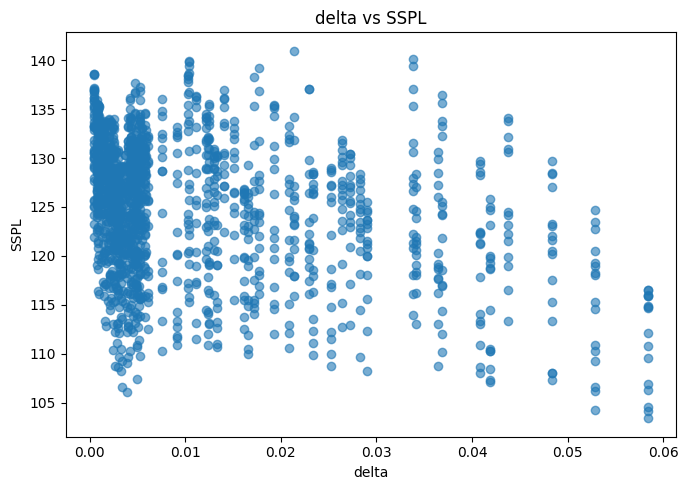

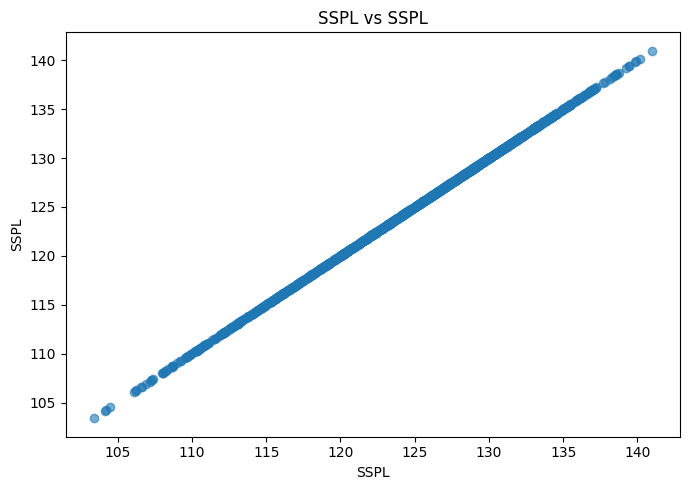

In [7]:
for col in df.columns:
    scatter_feature_vs_target(df, feature=col, target="SSPL")